# Riff 1

In [15]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.io as pio

from gensim.corpora import Dictionary
from gensim.models import word2vec

from sklearn.manifold import TSNE as tsne   
pio.renderers.default = 'iframe'
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [16]:
import gensim
gensim.__version__

'4.4.0'

In [136]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    PARAS = OHCO[:3],
    CHAPS = OHCO[:2],
    BOOKS = OHCO[:1]
)
BAG = OHCO[:4]

In [135]:
TOKENS = pd.read_csv('Data\CORPUS\FULL_CORPUS.csv').dropna()
LIB = pd.read_csv('Data/LIB.csv')

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\school\AppData\Local\Temp\ipykernel_17648\1790426359.py:1: SyntaxWarning: invalid escape sequence '\C'
  TOKENS = pd.read_csv('Data\CORPUS\FULL_CORPUS.csv').dropna()
C:\Users\school\AppData\Local\Temp\ipykernel_17648\1790426359.py:1: DtypeWarning: Columns (5,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  TOKENS = pd.read_csv('Data\CORPUS\FULL_CORPUS.csv').dropna()


In [137]:
high_LIB = LIB[LIB['novel_type'] == "romance"]
high_TOKENS = TOKENS[TOKENS['book_id'].isin(high_LIB['book_id'])]
high_TOKENS =high_TOKENS.dropna().set_index(OHCO)

In [138]:
docs = high_TOKENS.groupby('chap_num').term_str.apply(list).tolist()
dictionary = Dictionary(docs)

w2v_params = dict(
    window = 2,
    vector_size = 200,
    min_count = 20, 
    workers = 4
)

model = word2vec.Word2Vec(docs, **w2v_params)
model.wv.vectors


WV = pd.DataFrame(model.wv.vectors, index=model.wv.index_to_key)
WV.index.name = 'term_str'
WV

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
term_str,,,,,,,,,,,,,,,,,,,,,
the,0.114382,0.041403,0.080291,0.132535,-0.057454,-0.161750,0.194197,0.311069,-0.061407,0.049077,...,0.145740,0.068873,-0.151873,-0.231770,0.184579,0.023807,-0.023556,-0.253202,-0.016479,0.032054
to,0.063710,-0.041586,-0.002179,0.112747,0.072408,-0.114784,0.124886,0.289892,-0.036603,0.054156,...,0.192950,0.034592,-0.169736,-0.178771,0.137261,0.006195,0.031092,-0.260950,-0.036666,-0.090840
of,0.092633,0.028358,0.015393,0.109808,-0.007488,-0.112371,0.181301,0.271339,-0.053388,0.054228,...,0.181141,0.053049,-0.189984,-0.220240,0.167621,0.022918,-0.057587,-0.270036,-0.006612,-0.037138
and,0.086632,0.018251,0.035404,0.111916,0.009934,-0.125177,0.161740,0.291192,-0.039982,0.042212,...,0.184581,0.048127,-0.178551,-0.203641,0.167662,0.012533,-0.005748,-0.274545,-0.027080,-0.040751
her,0.072142,0.011600,0.034461,0.138512,0.041846,-0.138737,0.171894,0.310866,-0.050837,0.037885,...,0.169554,0.067843,-0.162525,-0.188852,0.166429,0.012596,0.015382,-0.244324,-0.021359,-0.035548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
foot,0.040268,-0.040484,0.003228,0.093818,0.055362,-0.083577,0.075159,0.207444,-0.022131,0.036233,...,0.123657,0.018369,-0.103729,-0.111460,0.076463,0.002181,0.031763,-0.162018,-0.021727,-0.056154
receive,0.039220,-0.054239,-0.002433,0.098243,0.064801,-0.079526,0.074714,0.218092,-0.020692,0.033303,...,0.138644,0.021788,-0.104481,-0.109766,0.073929,0.001587,0.041396,-0.166626,-0.032816,-0.066524
honour,0.029698,-0.050399,-0.011840,0.095135,0.068182,-0.073323,0.061778,0.200028,-0.025279,0.028031,...,0.121471,0.020413,-0.097503,-0.086380,0.062954,0.001647,0.037326,-0.139864,-0.028653,-0.060395


In [139]:
PP = 40 #40 # Try 1, 100, etc.

tsne_engine = tsne(
    perplexity=PP, 
    n_components=2, 
    init='pca', 
    max_iter=2500, 
    random_state=23
)
TSNE = pd.DataFrame(
    tsne_engine.fit_transform(WV), 
    columns=['x','y'], 
    index=WV.index)
TSNE

,x,y
term_str,,
the,-17.851536,-18.729383
to,-17.747343,-12.124810
of,-18.441002,-18.468019
and,-18.390240,-17.824120
her,-17.486053,-17.291622
...,...,...
foot,34.946308,1.963780
receive,28.403170,6.379995
honour,38.698826,8.010364


In [141]:
px.scatter(TSNE.reset_index(), 'x', 'y', 
        text='term_str', 
        title = "TSNE for Romance Novels",
        hover_name='term_str',  
        # size='n',
        height=1000,
        width=1200)\
    .update_traces(
        mode='markers+text', 
        textfont=dict(color='black', size=14, family='Arial'),
        textposition='top center')\
    .write_image('Outputs/riff_1_romance.png')

# Riff 2

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [100]:
novels_corpus_file = "Data\CORPUS\FULL_CORPUS.csv"
novels_lib_file = "Data\LIB.csv"
salex_file = "Data\SENT\salex_nrc.csv"

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\school\AppData\Local\Temp\ipykernel_17648\235220307.py:1: SyntaxWarning: invalid escape sequence '\C'
  novels_corpus_file = "Data\CORPUS\FULL_CORPUS.csv"
C:\Users\school\AppData\Local\Temp\ipykernel_17648\235220307.py:2: SyntaxWarning: invalid escape sequence '\L'
  novels_lib_file = "Data\LIB.csv"
C:\Users\school\AppData\Local\Temp\ipykernel_17648\235220307.py:3: SyntaxWarning: invalid escape sequence '\S'
  salex_file = "Data\SENT\salex_nrc.csv"


In [101]:
# The OHCO of the corpus
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]

# Subset of columns from salex
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

In [102]:
SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [126]:
LIB = pd.read_csv(novels_lib_file).set_index('book_id').sort_index()
TOKENS = pd.read_csv(novels_corpus_file).set_index(OHCO).sort_index()
TOKENS = TOKENS.join(LIB)
TOKENS.head()

C:\Users\school\AppData\Local\Temp\ipykernel_17648\917752304.py:2: DtypeWarning: Columns (5,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  TOKENS = pd.read_csv(novels_corpus_file).set_index(OHCO).sort_index()


pos_tuple  pos token_str  \
book_id chap_num para_num sent_num token_num                            
43      1        0        0        0               NaN  NaN       Mr.   
                                   1               NaN  NaN  Utterson   
                                   2               NaN  NaN       the   
                                   3               NaN  NaN    lawyer   
                                   4               NaN  NaN       was   

                                              term_str pos_group short_name  \
book_id chap_num para_num sent_num token_num                                  
43      1        0        0        0                mr       NaN     jekyll   
                                   1          utterson       NaN     jekyll   
                                   2               the       NaN     jekyll   
                                   3            lawyer       NaN     jekyll   
                                   4               was       NaN     jekyll   

                                                    era  date novel_type  
book_id chap_num para_num sent_num token_num                              
43      1        0        0        0          victorian  1886   thriller  
                                   1          victorian  1886   thriller  
                                   2          victorian  1886   thriller  
                                   3          victorian  1886   thriller  
                                   4          victorian  1886   thriller

In [127]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left') #.fillna(0)
TOKENS_SA

pos_tuple  pos token_str  \
book_id  chap_num para_num sent_num token_num                            
43       1        0        0        0               NaN  NaN       Mr.   
                                    1               NaN  NaN  Utterson   
                                    2               NaN  NaN       the   
                                    3               NaN  NaN    lawyer   
                                    4               NaN  NaN       was   
...                                                 ...  ...       ...   
20180856 9        119      4        34              NaN  WDT  whatever   
                                    35              NaN  VBD    walked   
                                    36              NaN   RB     there   
                                    38              NaN  VBD    walked   
                                    39              NaN   RB     alone   

                                               term_str pos_group  \
book_id  chap_num para_num sent_num token_num                       
43       1        0        0        0                mr       NaN   
                                    1          utterson       NaN   
                                    2               the       NaN   
                                    3            lawyer       NaN   
                                    4               was       NaN   
...                                                 ...       ...   
20180856 9        119      4        34         whatever        WD   
                                    35           walked        VB   
                                    36            there        RB   
                                    38           walked        VB   
                                    39            alone        RB   

                                                           short_name  \
book_id  chap_num para_num sent_num token_num                           
43       1        0        0        0                          jekyll   
                                    1                          jekyll   
                                    2                          jekyll   
                                    3                          jekyll   
                                    4                          jekyll   
...                                                               ...   
20180856 9        119      4        34         haunting_of_hill_house   
                                    35         haunting_of_hill_house   
                                    36         haunting_of_hill_house   
                                    38         haunting_of_hill_house   
                                    39         haunting_of_hill_house   

                                                     era  date novel_type  \
book_id  chap_num para_num sent_num token_num                               
43       1        0        0        0          victorian  1886   thriller   
                                    1          victorian  1886   thriller   
                                    2          victorian  1886   thriller   
                                    3          victorian  1886   thriller   
                                    4          victorian  1886   thriller   
...                                                  ...   ...        ...   
20180856 9        119      4        34            modern  1959   thriller   
                                    35            modern  1959   thriller   
                                    36            modern  1959   thriller   
                                    38            modern  1959   thriller   
                                    39            modern  1959   thriller   

                                               anger  anticipation  disgust  \
book_id  chap_num para_num sent_num token_num                                 
43       1        0        0        0            NaN           NaN      NaN

In [132]:
era_order = ['high', 'classic', 'victorian', 'modern']
BOOK_SA = TOKENS_SA.fillna(0).groupby('era')[emo_cols].mean().reindex(era_order)


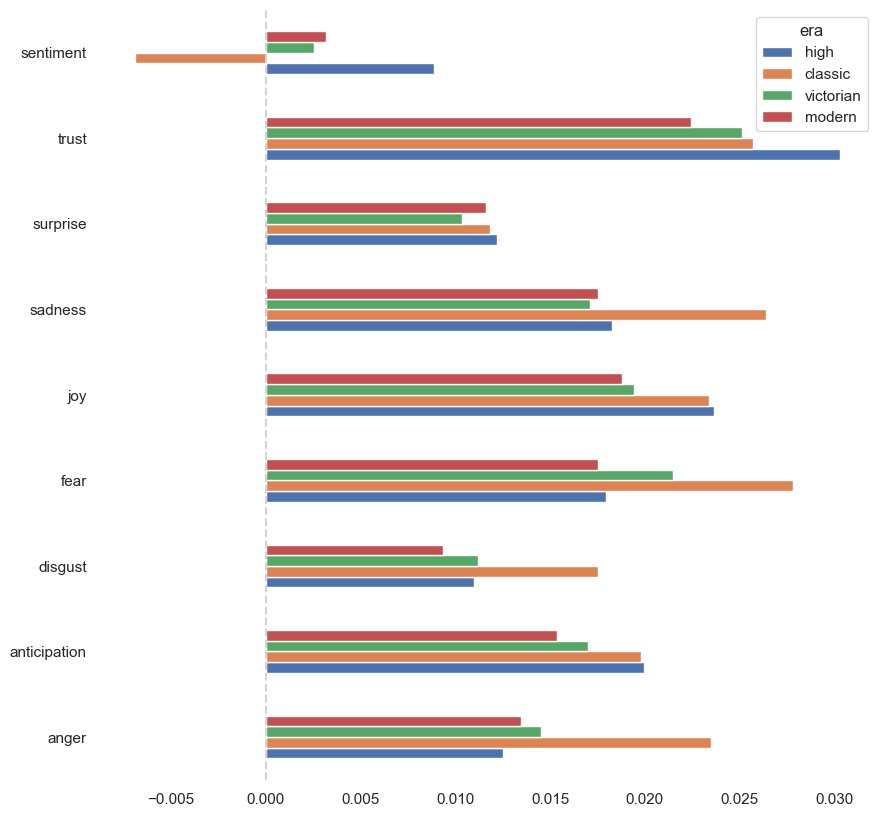

In [133]:
ax = BOOK_SA.T.plot.barh(figsize=(10,10))
ax.axvline(0, c='lightgray', ls='--')
sns.despine(left=True, bottom=True)
plt.show()

# Riff 3

In [42]:

OHCO = ['book_id', 'chap_num']
bag = 'CHAPS'
colors = "YlGnBu"
tf_agg = 'sum'

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm
from scipy.spatial.distance import pdist

sns.set_theme(style='white')

In [63]:
TFIDF_BAG = pd.read_csv("Data\TFIDF.csv").set_index(OHCO)
LIB = pd.read_csv('Data\LIB.csv').set_index('book_id')

# Normalize TFIDF_BAG: center around 0 (z-score normalization)
TFIDF_BAG = (TFIDF_BAG - TFIDF_BAG.mean()) / TFIDF_BAG.std()

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\school\AppData\Local\Temp\ipykernel_17648\375764622.py:1: SyntaxWarning: invalid escape sequence '\T'
  TFIDF_BAG = pd.read_csv("Data\TFIDF.csv").set_index(OHCO)
C:\Users\school\AppData\Local\Temp\ipykernel_17648\375764622.py:2: SyntaxWarning: invalid escape sequence '\L'
  LIB = pd.read_csv('Data\LIB.csv').set_index('book_id')


In [90]:
LIB['label'] = LIB.date.astype('str') + ': ' +  LIB.short_name 
LIB['label'] = LIB.label.str.title()
LIB.label


book_id
43                          1886: Jekyll
41445                 1818: Frankenstein
175           1910: Phantom_Of_The_Opera
345                        1897: Dracula
696                        1764: Otranto
1952               1892: Yellow_Walpaper
3268                       1794: Udolpho
5182                         1778: Baron
6087                       1819: Vampyre
12122                   1902: Monkey_Paw
53685                      1820: Melmoth
20180856    1959: Haunting_Of_Hill_House
Name: label, dtype: object

In [64]:
TFIDF_BAG

000         1        10       100      1018      1030  \
book_id  chap_num                                                               
43       1         0.250545 -0.097672  0.168911  0.254436  0.244517  0.224874   
         2        -0.063997 -0.322656 -0.133397 -0.060725 -0.067911 -0.079168   
         3         3.882627  2.500257  3.659724  3.893658  3.852186  3.735704   
         4         0.582824  0.139998  0.488267  0.587368  0.574563  0.546060   
         5         1.049681  0.473928  0.936965  1.055142  1.038281  0.997332   
...                     ...       ...       ...       ...       ...       ...   
20180856 5        -0.653030 -0.743975 -0.699520 -0.650916 -0.652985 -0.648537   
         6         0.040530 -0.247890 -0.032935  0.044008  0.035914  0.021870   
         7        -0.608251 -0.711945 -0.656482 -0.606048 -0.608506 -0.605252   
         8        -0.230581 -0.441808 -0.293501 -0.227636 -0.233375 -0.240190   
         9        -0.512732 -0.643623 -0.564678 -0.510342 -0.513630 -0.512922   

                       10th        11      1140      11th  ...  zoöphagy  \
book_id  chap_num                                          ...             
43       1         0.253553  0.148338  0.248718  0.249695  ...  0.245215   
         2        -0.061541 -0.144743 -0.065301 -0.064619  ... -0.067509   
         3         3.892000  3.532600  3.874754  3.879138  ...  3.856298   
         4         0.586414  0.457945  0.580444  0.581733  ...  0.575573   
         5         1.054089  0.892948  1.046523  1.048250  ...  1.039730   
...                     ...       ...       ...       ...  ...       ...   
20180856 5        -0.651606 -0.693586 -0.653354 -0.653224  ... -0.653137   
         6         0.043170 -0.047347  0.039052  0.039833  ...  0.036414   
         7        -0.606748 -0.651862 -0.608649 -0.608477  ... -0.608616   
         8        -0.228416 -0.299960 -0.231607 -0.231081  ... -0.233129   
         9        -0.511062 -0.562860 -0.513289 -0.513028  ... -0.513649   

                     zurich         à     æneis       æra        æt      ætat  \
book_id  chap_num                                                               
43       1         0.248516  0.204912  0.256539  0.238591  0.244144  0.233799   
         2        -0.065438  2.297120 -0.058540 -0.070937 -0.068121 -0.072986   
         3         3.873805  3.747041  3.894816  3.812772  3.849937  3.776308   
         4         0.580174  0.528962  0.589385  0.565573  0.574018  0.557884   
         5         1.046157  0.984256  1.057038  1.024987  1.037496  1.013227   
...                     ...       ...       ...       ...       ...       ...   
20180856 5        -0.653369  0.573785 -0.648578 -0.650580 -0.652891 -0.647492   
         6         0.038894  0.000098  0.046166  0.031924  0.035650  0.028964   
         7        -0.608673 -0.632615 -0.603722 -0.606514 -0.608435 -0.603817   
         8        -0.231710 -0.264299 -0.225407 -0.234865 -0.233499 -0.235461   
         9        -0.513333 -0.539462 -0.508040 -0.512518 -0.513608 -0.510654   

                      æther      état    œdipus  
book_id  chap_num                                
43       1         0.235193  0.255112  0.256539  
         2        -0.080262 -0.060063 -0.058540  
         3         3.877814  3.894502  3.894816  
         4         0.568436  0.588060  0.589385  
         5         1.036647  1.055856  1.057038  
...                     ...       ...       ...  
20180856 5        -0.671005 -0.650281 -0.648578  
         6         0.024568  0.044675  0.046166  
         7        -0.626095 -0.605411 -0.603722  
         8        -0.247329 -0.226981 -0.225407  
         9        -0.530299 -0.509700 -0.508040  

[125 rows x 21504 columns]

In [65]:
TFIDF = TFIDF_BAG.groupby(OHCO[:1]).mean()
TFIDF


,000,1,10,100,1018,1030,10th,11,1140,11th,...,zoöphagy,zurich,à,æneis,æra,æt,ætat,æther,état,œdipus
book_id,,,,,,,,,,,,,,,,,,,,,
43,1.370285,0.703248,1.245099,1.376377,1.356731,1.307233,1.467001,1.191677,1.366594,1.368622,...,1.358481,1.366162,1.563471,1.378189,1.340480,1.355779,1.325925,1.358182,1.377105,1.378189
175,0.208084,0.435039,0.128101,0.239670,0.202341,0.183830,0.211017,0.108774,0.206327,0.207265,...,0.202999,0.257583,0.163502,0.214005,0.196806,0.201990,0.192385,0.192608,0.212566,0.214005
345,-0.439342,0.022774,-0.193370,-0.479289,-0.420621,-0.361856,-0.480016,-0.131507,-0.433491,-0.482059,...,-0.422712,-0.482400,-0.448143,-0.476996,-0.482021,-0.419511,-0.390153,-0.499218,-0.478646,-0.476996
696,-0.652687,-0.743730,-0.699190,-0.650572,-0.652644,-0.648206,-0.651263,-0.693266,-0.653011,-0.652881,...,-0.652796,-0.653027,-0.675951,-0.648234,-0.650243,-0.652550,-0.647158,-0.670661,-0.649937,-0.648234
1952,-0.535375,-0.659820,-0.586441,-0.533030,-0.536121,-0.534810,-0.533745,-0.583959,-0.535895,-0.535655,...,-0.536162,-0.535934,-0.561545,-0.530722,-0.534801,-0.536088,-0.532739,-0.553009,-0.532389,-0.530722
3268,-0.307911,-0.497120,-0.367824,-0.305118,-0.310185,-0.314939,-0.305882,-0.372014,-0.308809,-0.308355,...,-0.310013,-0.308895,-0.282299,-0.302870,-0.310963,-0.310270,-0.310884,-0.081958,-0.304467,-0.302870
5182,-1.204636,-1.138524,-1.229672,-1.203606,-1.200883,-1.181729,-1.204179,-1.207556,-1.204042,-1.204429,...,-1.201554,-1.203944,-1.214231,-1.201125,-1.193393,-1.200504,-1.185495,-1.224211,-1.202997,-1.201125
6087,0.785287,1.201663,0.682855,0.790229,0.775665,0.741765,0.789232,0.646594,0.782570,0.784049,...,0.776866,0.782258,0.726410,0.792193,0.764808,0.775016,0.755354,0.771487,0.790931,0.792193
12122,1.225544,0.599718,1.105988,1.231351,1.212963,1.167324,1.230261,1.056812,1.222094,1.223986,...,1.214577,1.221692,1.155764,1.233201,1.198047,1.212086,1.184753,1.213021,1.232073,1.233201


In [70]:
V = TFIDF_BAG.mean().to_frame('mean_tfidf')
V.index.name = 'term_str'
N = len(TFIDF_BAG)
V['dp'] = V.mean_tfidf / N
V['di'] = np.log2(1/V.dp)
V['dh'] = V.dp * V.di
V.sample(5)

C:\Users\school\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,mean_tfidf,dp,di,dh
term_str,,,,
thonon,1.368239e-14,1.094591e-16,53.020458,5.803572e-15
helpful,3.577583e-14,2.862066e-16,51.633793,1.477793e-14
injunctions,-2.253309e-15,-1.802647e-17,NaN,NaN
opiate,1.983480e-14,1.586784e-16,52.484744,8.328195e-15
conversations,2.023981e-14,1.619185e-16,52.455582,8.493528e-15


In [73]:
sig_thresh = 0
SIGS = V[V.dh >= sig_thresh]
(len(SIGS) / len(V)) * 100, len(SIGS)

(44.49404761904761, 9568)

In [74]:
SIGS.sample(5)


,mean_tfidf,dp,di,dh
term_str,,,,
deskchair,2.617462e-15,2.093969e-17,55.406537,1.160196e-15
mistlike,1.637446e-14,1.309957e-16,52.761331,6.911505e-15
serves,7.101875e-15,5.681500e-17,53.966506,3.066107e-15
dirty,1.232792e-14,9.862333e-17,53.170849,5.243886e-15
habit,1.600764e-14,1.280611e-16,52.794017,6.760861e-15


In [75]:
TFIDF_SIGS = TFIDF[SIGS.index].copy()
TFIDF_SIGS

term_str,1,100,1030,10th,1140,12th,13,14th,15th,16,...,youyou,yus,z,zeal,zinc,zoo,zoöphagous,zoöphagy,ætat,æther
book_id,,,,,,,,,,,,,,,,,,,,,
43,0.703248,1.376377,1.307233,1.467001,1.366594,1.593451,1.323123,1.661133,1.661133,1.320306,...,1.367853,1.312408,1.366594,0.980989,1.367246,1.352341,1.252998,1.358481,1.325925,1.358182
175,0.435039,0.239670,0.183830,0.211017,0.206327,0.110732,0.166752,0.150462,0.150462,0.192535,...,0.206902,0.185339,0.206327,0.041722,0.256261,0.200756,0.137176,0.202999,0.192385,0.192608
345,0.022774,-0.479289,-0.361856,-0.480016,-0.433491,-0.412438,-0.311156,-0.443792,-0.443792,-0.311276,...,-0.482180,-0.366339,-0.433491,-0.486063,-0.482266,-0.415630,-0.194580,-0.422712,-0.390153,-0.499218
696,-0.743730,-0.650572,-0.648206,-0.651263,-0.653011,-0.617065,-0.689701,-0.591056,-0.591056,-0.690709,...,-0.652943,-0.649411,-0.653011,0.188070,-0.652980,-0.652152,-0.689244,-0.652796,-0.647158,-0.670661
1952,-0.659820,-0.533030,-0.534810,-0.533745,-0.535895,-0.517876,-0.572978,-0.489997,-0.489997,-0.574091,...,-0.535757,-0.535646,-0.535895,-0.559126,-0.535828,-0.535912,-0.576614,-0.536162,-0.532739,-0.553009
3268,-0.497120,-0.305118,-0.314939,-0.305882,-0.308809,-0.325550,-0.346655,-0.294046,-0.294046,-0.347971,...,-0.308537,-0.315057,-0.308809,-0.311142,-0.308672,-0.310525,-0.358227,-0.310013,-0.310884,-0.081958
5182,-1.138524,-1.203606,-1.181729,-1.204179,-1.204042,-1.083747,-1.238882,-1.066536,-1.066536,-1.239396,...,-1.204298,-1.184675,-1.204042,-1.100008,-1.204180,-1.199059,-1.219167,-1.201554,-1.185495,-1.224211
6087,1.201663,0.790229,0.741765,0.789232,0.782570,0.598768,0.741060,0.647698,0.647698,0.738766,...,0.783485,0.745095,0.782570,0.508206,0.783042,0.772687,0.691345,0.776866,0.755354,0.771487
12122,0.599718,1.231351,1.167324,1.230261,1.222094,0.971013,1.179108,1.026960,1.026960,1.176420,...,1.223268,1.172043,1.222094,0.864012,1.222701,1.208922,1.114033,1.214577,1.184753,1.213021


In [76]:
L0 = TFIDF_SIGS.astype('bool').astype('int')    # Binary (Pseudo L)
L1 = TFIDF_SIGS.apply(lambda x: x / x.sum(), 1) # Probabilistic
L2 = TFIDF_SIGS.apply(lambda x: x / norm(x), 1) # Pythagorean, AKA Euclidean

In [ ]:
def plot_doc_in_terms(t1, t2):
    from matplotlib.patches import Patch
    ax = L1.plot.scatter(t1, t2, figsize=(10,10))
    for i, row in L1.iterrows():
        label = LIB.loc[i]['label']
        year = int(label[:4])
        color = 'green' if (1700 <= year <= 1850) else 'blue'
        x_pad = L1[t1].max() * .01
        ax.annotate(label, xy=(row[t1] + x_pad, row[t2]), c=color)
    sns.despine()
    plt.title("Documents in Term Space", fontweight='bold')
    # Add legend
    legend_elements = [Patch(facecolor='green', label='1700-1850'),
                       Patch(facecolor='blue', label='1850 onwards')]
    ax.legend(handles=legend_elements)
    plt.show()

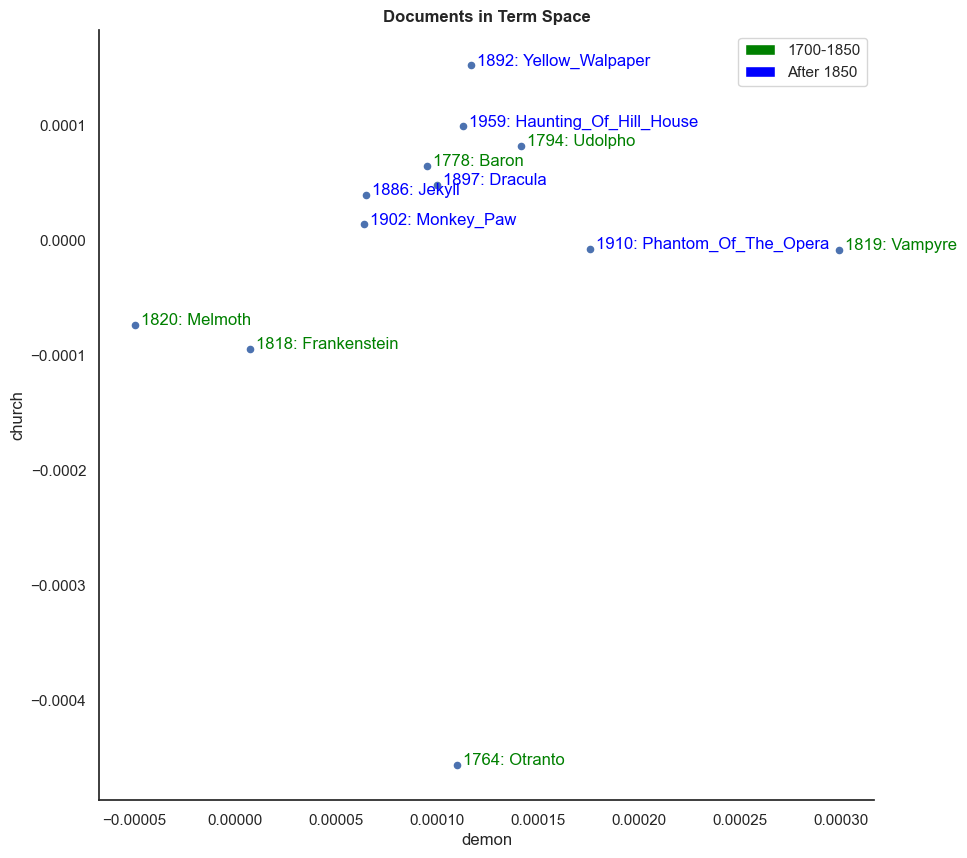

In [98]:
plot_doc_in_terms('demon', 'church')
